In [1]:
from openai import OpenAI

client = OpenAI(api_key="YOUR_OPENAI_API_KEY")

# List all fine-tuning jobs
jobs = client.fine_tuning.jobs.list()

# Find the job that generated your model
target_model = "ft:gpt-4.1-mini-2025-04-14:personal::DCd6cV35"
job_id = None
for job in jobs:
    if job.fine_tuned_model == target_model:
        job_id = job.id
        break

print(f"Job ID: {job_id}")

Job ID: ftjob-pRzl1MpZ945WH7EE93aHqqX8


In [7]:
import base64
import csv
import io
import matplotlib.pyplot as plt
from openai import OpenAI

client = OpenAI(api_key="YOUR_OPENAI_API_KEY")

# Retrieve the fine-tuning job
job = client.fine_tuning.jobs.retrieve(job_id)

# Get the result file ID
result_file_id = job.result_files[0]

# Download the file content (this returns a base64‑encoded string)
response = client.files.content(result_file_id)
base64_str = response.text   # or response.read().decode('utf-8') in some versions

# Decode base64 to CSV text
csv_bytes = base64.b64decode(base64_str.encode('utf-8'))
csv_text = csv_bytes.decode('utf-8')

# Parse the CSV
reader = csv.DictReader(io.StringIO(csv_text))
metrics = []
for row in reader:
    # Convert numeric fields to float; handle possible empty strings
    step = int(row['step'])
    train_loss = float(row['train_loss'])
    train_accuracy = float(row['train_accuracy'])
    valid_loss = float(row['valid_loss']) if row['valid_loss'] else None
    valid_mean_token_accuracy = float(row['valid_mean_token_accuracy']) if row['valid_mean_token_accuracy'] else None
    metrics.append({
        'step': step,
        'train_loss': train_loss,
        'train_accuracy': train_accuracy,
        'valid_loss': valid_loss,
        'valid_mean_token_accuracy': valid_mean_token_accuracy
    })

print(f"Parsed {len(metrics)} rows.")

Parsed 711 rows.


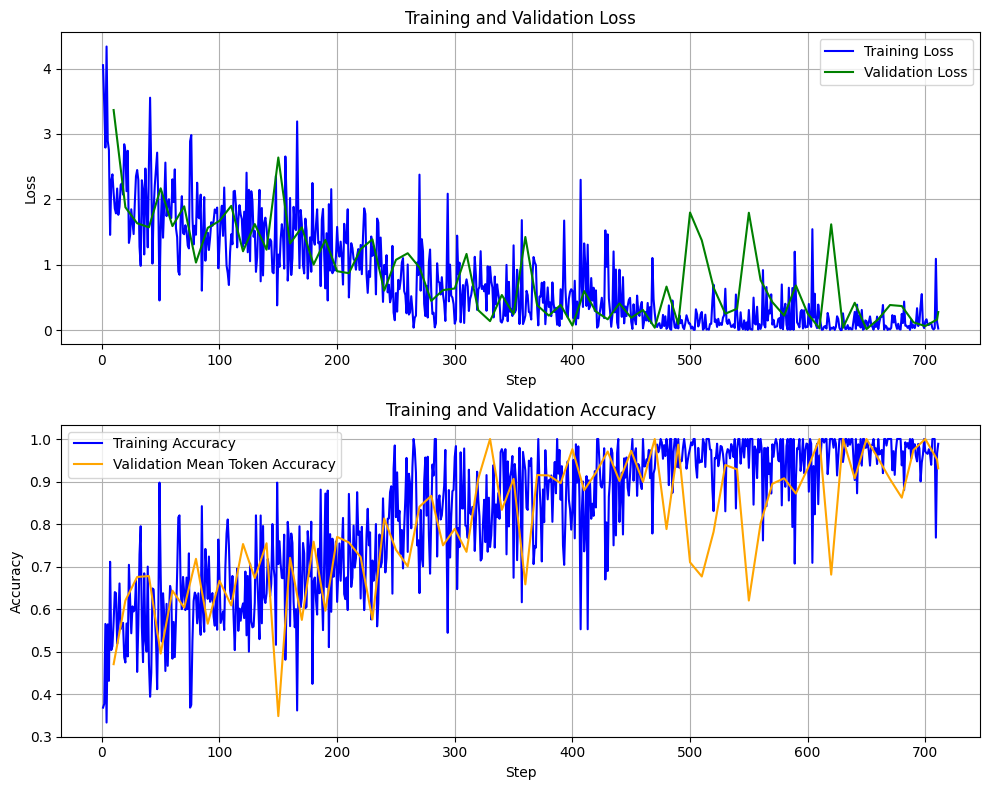

In [8]:
# Extract data for plotting
steps = [m['step'] for m in metrics]
train_loss = [m['train_loss'] for m in metrics]
train_acc = [m['train_accuracy'] for m in metrics]

# Validation data (only where present)
valid_steps = [m['step'] for m in metrics if m['valid_loss'] is not None]
valid_loss = [m['valid_loss'] for m in metrics if m['valid_loss'] is not None]
valid_acc_steps = [m['step'] for m in metrics if m['valid_mean_token_accuracy'] is not None]
valid_acc = [m['valid_mean_token_accuracy'] for m in metrics if m['valid_mean_token_accuracy'] is not None]

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Loss plot
ax1.plot(steps, train_loss, label='Training Loss', color='blue')
if valid_loss:
    ax1.plot(valid_steps, valid_loss, label='Validation Loss', color='green')
ax1.set_xlabel('Step')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(steps, train_acc, label='Training Accuracy', color='blue')
if valid_acc:
    ax2.plot(valid_acc_steps, valid_acc, label='Validation Mean Token Accuracy', color='orange')
ax2.set_xlabel('Step')
ax2.set_ylabel('Accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()